# **Phase 2: Exploratory Data Analysis**

## **Libraries**

In [ ]:
# Basic System & Math Utilities
import os
import math
import glob

# Audio Processing Libraries
import wave
import librosa
import librosa.display
import soundfile
from scipy.io.wavfile import read

# Data Handling & Numerical Computing
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Visualization Tools
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Machine Learning / Deep Learning
import tensorflow as tf
from tqdm.notebook import tqdm

# Jupyter Audio Playback
import IPython.display as ipd

from tqdm.notebook import tqdm

## **Explore Dataset Directory**

In [ ]:
import kagglehub
vbookshelf_respiratory_sound_database_path = kagglehub.dataset_download('vbookshelf/respiratory-sound-database')

print('Data source import complete.')

100%|██████████| 3.69G/3.69G [00:52<00:00, 75.5MB/s]

Extracting files...


Data source import complete.


The dataset used in this study is the Respiratory Sound Database, originally acquired from the Biomedical Health Informatics Challenge hosted by Aristotle University of Thessaloniki (Rocha et al., 2019). This database was curated by research teams from Portugal and Greece and is publicly accessible via Kaggle.

The dataset comprises 920 annotated audio recordings of respiratory sounds from 126 patients, with clips ranging from 10 to 90 seconds in length. Each recording includes corresponding annotation files that describe the presence of respiratory anomalies such as wheezes, crackles, or both, as well as demographic and diagnostic information for each patient. The dataset offers a comprehensive repository of real-world respiratory sound data, suitable for training and evaluating machine learning models targeting respiratory disease detection.

In [ ]:
os.listdir(vbookshelf_respiratory_sound_database_path)

['demographic_info.txt',
 'respiratory_sound_database',
 'Respiratory_Sound_Database']

#### **Load and Merge Demographics & Diagnosis CSVs**

In [ ]:
df_no_diagnosis = pd.read_csv(
    os.path.join(vbookshelf_respiratory_sound_database_path, 'demographic_info.txt'),
    names=['Patient number', 'Age', 'Sex', 'Adult BMI (kg/m2)',
           'Child Weight (kg)', 'Child Height (cm)'],
    delimiter=' '
)

diagnosis = pd.read_csv(
    os.path.join(vbookshelf_respiratory_sound_database_path, 'Respiratory_Sound_Database',
                 'Respiratory_Sound_Database', 'patient_diagnosis.csv'),
    names=['Patient number', 'Diagnosis']
)

In [ ]:
# Merge demographics + diagnosis
df = df_no_diagnosis.join(
    diagnosis.set_index('Patient number'),
    on='Patient number',
    how='left'
)

df

,Patient number,Age,Sex,Adult BMI (kg/m2),Child Weight (kg),Child Height (cm),Diagnosis
0,101,3.00,F,NaN,19.0,99.0,URTI
1,102,0.75,F,NaN,9.8,73.0,Healthy
2,103,70.00,F,33.00,NaN,NaN,Asthma
3,104,70.00,F,28.47,NaN,NaN,COPD
4,105,7.00,F,NaN,32.0,135.0,URTI
...,...,...,...,...,...,...,...
121,222,60.00,M,NaN,NaN,NaN,COPD
122,223,NaN,NaN,NaN,NaN,NaN,COPD
123,224,10.00,F,NaN,32.3,143.0,Healthy
124,225,0.83,M,NaN,7.8,74.0,Healthy


#### **List All Filenames**

In [ ]:
root = os.path.join(vbookshelf_respiratory_sound_database_path, 'Respiratory_Sound_Database', 'Respiratory_Sound_Database', 'audio_and_txt_files') + os.sep

filenames = [s.split('.')[0] for s in os.listdir(root) if s.endswith('.txt')]

#### **Function to Extract Annotation Data**

In [ ]:
def Extract_Annotation_Data(file_name, root):
    tokens = file_name.split('_')

    recording_info = pd.DataFrame(
        data=[tokens],
        columns=['Patient number', 'Recording index',
                 'Chest location', 'Acquisition mode', 'Recording equipment']
    )

    recording_annotations = pd.read_csv(
        os.path.join(root, file_name + '.txt'),
        names=['Start', 'End', 'Crackles', 'Wheezes'],
        delimiter='\t'
    )

    return recording_info, recording_annotations

#### **Collect Recording Info & Annotation Dictionaries**

In [ ]:
i_list = []
rec_annotations_dict = {}

for s in filenames:
    info, ann = Extract_Annotation_Data(s, root)
    i_list.append(info)
    rec_annotations_dict[s] = ann

recording_info = pd.concat(i_list, axis=0)
recording_info.tail()

,Patient number,Recording index,Chest location,Acquisition mode,Recording equipment
0,188,1b1,Ar,sc,Meditron
0,186,3b3,Lr,mc,AKGC417L
0,158,1p3,Pr,mc,AKGC417L
0,136,1b1,Ar,sc,Meditron
0,107,2b4,Lr,mc,AKGC417L


#### **Count Crackles/Wheezes Per File**

In [ ]:
filename_list = []
no_label_list = []
crack_list = []
wheeze_list = []
both_sym_list = []

for f in filenames:
    d = rec_annotations_dict[f]

    no_label = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 0)])
    crack_only = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 0)])
    wheeze_only = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 1)])
    both = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 1)])

    filename_list.append(f)
    no_label_list.append(no_label)
    crack_list.append(crack_only)
    wheeze_list.append(wheeze_only)
    both_sym_list.append(both)

file_label_df = pd.DataFrame({
    'filename': filename_list,
    'no label': no_label_list,
    'crackles only': crack_list,
    'wheezes only': wheeze_list,
    'crackles and wheezees': both_sym_list
})

#### **Aggregate & Assign Diagnosis Labels**

In [ ]:
labels = file_label_df.sort_values(by='filename')
summary = labels.groupby('filename').sum()

conditions = [
    (summary['crackles only'] == 0) &
    (summary['wheezes only'] == 0) &
    (summary['crackles and wheezees'] == 0),

    (summary['crackles only'] == summary.max(axis=1)),
    (summary['wheezes only'] == summary.max(axis=1)),
    (summary['crackles and wheezees'] == summary.max(axis=1)),

    (summary['no label'] == summary.max(axis=1)) &
    (summary['crackles only'] > summary['wheezes only']) &
    (summary['crackles only'] > summary['crackles and wheezees']),

    (summary['no label'] == summary.max(axis=1)) &
    (summary['wheezes only'] >= summary['crackles only']) &
    (summary['wheezes only'] > summary['crackles and wheezees']),

    (summary['no label'] == summary.max(axis=1)) &
    (summary['crackles and wheezees'] >= summary['crackles only']) &
    (summary['crackles and wheezees'] >= summary['wheezes only']),
]

values = [
    'Healthy',
    'Crackles',
    'Wheezes',
    'Wheezes & Crackles',
    'Crackles',
    'Wheezes',
    'Wheezes & Crackles'
]

summary['diagnosis'] = np.select(conditions, values, default='Unknown')
summary

,no label,crackles only,wheezes only,crackles and wheezees,diagnosis
filename,,,,,
101_1b1_Al_sc_Meditron,12,0,0,0,Healthy
101_1b1_Pr_sc_Meditron,11,0,0,0,Healthy
102_1b1_Ar_sc_Meditron,13,0,0,0,Healthy
103_2b2_Ar_mc_LittC2SE,2,0,4,0,Wheezes
104_1b1_Al_sc_Litt3200,6,0,0,0,Healthy
...,...,...,...,...,...
224_1b2_Al_sc_Meditron,7,0,0,0,Healthy
225_1b1_Pl_sc_Meditron,14,0,0,0,Healthy
226_1b1_Al_sc_Meditron,8,2,0,0,Crackles


# **Exploratory Data Analysis**

#### **Basic Overview of Demographic Dataset**

In [ ]:
print("Shape of demographics dataframe:", df.shape)
df.head()

Shape of demographics dataframe: (126, 7)


,Patient number,Age,Sex,Adult BMI (kg/m2),Child Weight (kg),Child Height (cm),Diagnosis
0,101,3.00,F,NaN,19.0,99.0,URTI
1,102,0.75,F,NaN,9.8,73.0,Healthy
2,103,70.00,F,33.00,NaN,NaN,Asthma
3,104,70.00,F,28.47,NaN,NaN,COPD
4,105,7.00,F,NaN,32.0,135.0,URTI


In [ ]:
# Check missing values
df.isnull().sum()

,0
Patient number,0
Age,1
Sex,1
Adult BMI (kg/m2),51
Child Weight (kg),82
Child Height (cm),84
Diagnosis,0


In [ ]:
# Summary statistics
df.describe(include='all')

,Patient number,Age,Sex,Adult BMI (kg/m2),Child Weight (kg),Child Height (cm),Diagnosis
count,126.000000,125.00000,125,75.000000,44.000000,42.000000,126
unique,NaN,NaN,2,NaN,NaN,NaN,8
top,NaN,NaN,M,NaN,NaN,NaN,COPD
freq,NaN,NaN,79,NaN,NaN,NaN,64
mean,163.500000,42.99264,NaN,27.190000,21.361136,104.652381,NaN
std,36.517119,32.20907,NaN,5.372519,17.150885,30.793128,NaN
min,101.000000,0.25000,NaN,16.500000,7.140000,64.000000,NaN
25%,132.250000,4.00000,NaN,24.150000,11.755000,81.250000,NaN
50%,163.500000,60.00000,NaN,27.400000,15.100000,99.500000,NaN
75%,194.750000,71.00000,NaN,29.185000,24.325000,117.750000,NaN


#### **Diagnosis Distribution**

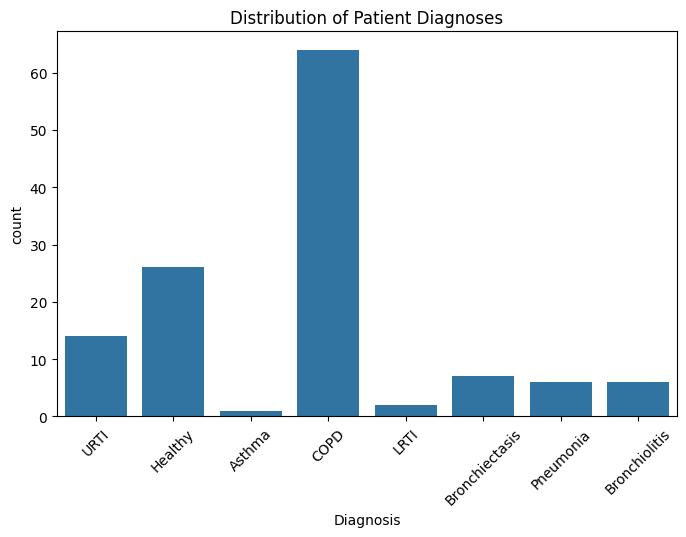

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Diagnosis')
plt.title("Distribution of Patient Diagnoses")
plt.xticks(rotation=45)
plt.show()

This bar chart shows the distribution of patient diagnoses in the dataset by count.

### Dominant and Minority Classes

- **COPD** (Chronic Obstructive Pulmonary Disease) is the most represented diagnosis by far, with over 60 patients, making it the majority class in this sample.
- **Healthy** individuals form the second largest group, with just over 25 cases, providing a sizeable control population for comparative analysis.
- **URTI** (Upper Respiratory Tract Infection) is also notable, but substantially fewer than COPD and Healthy, with around 15 cases.
- Diagnoses like **Asthma, LRTI** (Lower Respiratory Tract Infection), **Bronchiectasis**, **Pneumonia**, and **Bronchiolitis** are minority classes, each with less than 10 cases, indicating limited sampling or rarity in the dataset.

### Analytical Implications

- The diagnosis distribution is highly imbalanced, especially with the dominance of COPD and the scarcity of less common conditions.
- Models trained on this dataset may require strategies to handle class imbalance, such as oversampling minority classes, using class weights, or designing specific evaluation metrics to prevent bias toward COPD detection.
- The strong representation of Healthy and COPD is beneficial for discriminative modeling but highlights the risk of reduced sensitivity and lower generalizability for rare diseases (e.g., Asthma, Bronchiolitis).

### Epidemiological Considerations

- High COPD counts may reflect real-world prevalence patterns, especially in older, smoking, or at-risk populations, or could be due to targeted recruitment in the dataset.
- The rarity of asthma and select infections could indicate these conditions are less prevalent in the sampled cohort or might result from inclusion criteria and annotation emphasis.

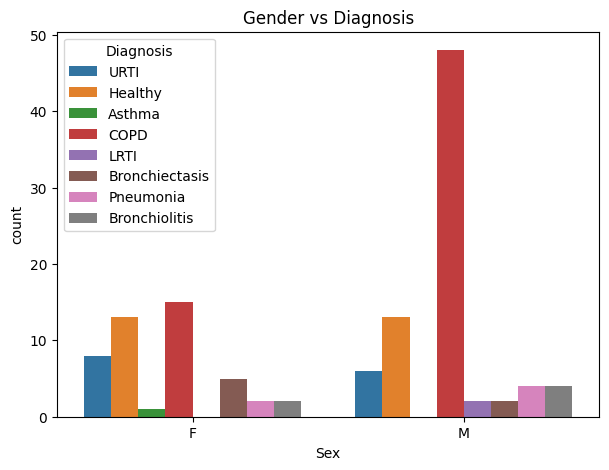

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Sex', hue='Diagnosis')
plt.title("Gender vs Diagnosis")
plt.show()

This grouped bar chart displays counts of recordings by diagnosis and sex (female "F" and male "M") for several respiratory conditions.

### Major Trends

- **COPD** (Chronic Obstructive Pulmonary Disease) shows a strong male predominance, with more than triple the number of male cases compared to females.
- **Healthy** individuals are distributed equally between sexes, suggesting the reference population is balanced.
- **URTI** (Upper Respiratory Tract Infection), **Bronchiectasis**, **Pneumonia**, and **Bronchiolitis** have lower and fairly balanced counts across both sexes, indicating no strong gender bias in sample collection for these conditions.

### Observations

- **Asthma** is notably rare in this subset, with only 1 female case and none in males—highlighting potential sampling or annotation limitations for this diagnosis.
- **LRTI** (Lower Respiratory Tract Infection) is more frequent in males but remains one of the less common classes overall.

#### **Overview of Audio-Based Labels**

In [ ]:
summary.head()

,no label,crackles only,wheezes only,crackles and wheezees,diagnosis
filename,,,,,
101_1b1_Al_sc_Meditron,12,0,0,0,Healthy
101_1b1_Pr_sc_Meditron,11,0,0,0,Healthy
102_1b1_Ar_sc_Meditron,13,0,0,0,Healthy
103_2b2_Ar_mc_LittC2SE,2,0,4,0,Wheezes
104_1b1_Al_sc_Litt3200,6,0,0,0,Healthy


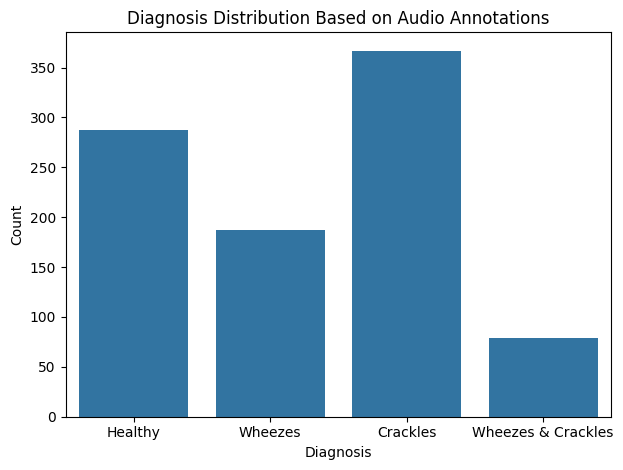

In [ ]:
sns.countplot(data=summary, x='diagnosis')
plt.title("Diagnosis Distribution Based on Audio Annotations")
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

This bar chart displays the count of audio recordings grouped by four diagnosis categories: Healthy, Wheezes, Crackles, and Wheezes & Crackles.

### Class Distribution

- **Crackles** have the largest number of samples, making up the most prevalent diagnosis in the dataset.
- **Healthy** samples represent the second largest group, suggesting a substantial baseline population for comparison.
- **Wheezes** occur less frequently than Crackles and Healthy, but are still well represented.
- **Wheezes & Crackles** (co-occurring pathology) has the fewest recordings, indicating that mixed or complex cases are relatively rare in this dataset.

### Analytical Implications

- The class distribution is imbalanced, a condition that must be addressed during model development to prevent algorithms from disproportionately favoring the majority class.
- Ensuring that all groups—particularly the dominant (Crackles) and the baseline (Healthy)—are adequately represented strengthens statistical power for feature analysis and diagnostic interpretation.
- The limited number of combined (Wheezes & Crackles) samples highlights the need for targeted strategies such as data augmentation, class weighting, or resampling to maintain model reliability and evaluation fairness.

In [ ]:
audio_lengths = []

for f in summary.index:
    wav_path = os.path.join(root, f + ".wav")
    try:
        y, sr = librosa.load(wav_path)
        audio_lengths.append(len(y) / sr)
    except:
        audio_lengths.append(None)

summary['duration_sec'] = audio_lengths
summary['duration_sec'].describe()

,duration_sec
count,920.000000
mean,21.492426
std,8.307423
min,7.856009
25%,20.000000
50%,20.000000
75%,20.000000
max,86.200000


This summarizes the distribution of audio clip durations in seconds for 920 samples.

### Central Tendency and Spread

- The **mean duration** is about 21.5 seconds, while the **standard deviation** is 8.3 seconds, indicating moderate variability across recordings.
- **Minimum duration** is 7.86 seconds, suggesting a lower bound typical for shorter lung sound recordings.
- **Maximum duration** is quite high at 86.2 seconds, likely due to a few outliers or extended recordings.

### Percentiles and Distribution Shape

- The **25th, 50th (median), and 75th percentiles** are all exactly 20 seconds, revealing a strong central clustering at this common value.
- Since most samples (at least three quartiles) are recorded for 20 seconds, the dataset is highly standardized, with a small fraction of much longer outliers driving up the mean and spread.
- The **median** equals the **lower and upper quartiles**, emphasizing the uniformity of duration for the bulk of the data.

### Analytical and Practical Insights

- Standardized duration (20 seconds) simplifies feature extraction and model training, as time-dependent features are directly comparable.
- Extended duration outliers may need handling (e.g., trimming, padding) to maintain homogeneity and prevent bias from abnormally long recordings.

In [ ]:
duration_summary = features_df.groupby('diagnosis')['duration_sec'].agg(['mean', 'min', 'max'])
print("Duration Summary by Diagnosis:")
duration_summary

Duration Summary by Diagnosis:


,mean,min,max
diagnosis,,,
Crackles,21.901635,14.576,82.50
Healthy,21.227730,7.856,86.20
Wheezes,20.825382,11.248,73.35
Wheezes & Crackles,22.131975,9.584,71.05


Within this dataset, the mean durations for healthy, wheeze, crackle, and combined wheeze–crackle recordings are all clustered in a narrow band around roughly 21–22 seconds, so the study concludes that each class offers a similar average amount of temporal information. This balance is important because it reduces the risk that any class systematically benefits from longer recordings (and therefore more respiratory cycles), supporting fairer comparisons in downstream classification. The broad range between minimum and maximum segment lengths within each class suggests that a few recordings are much shorter or longer than the typical segment, which the study highlights as a reason to apply pre-processing steps (e.g., fixed-length windowing) so that models receive inputs of comparable size.

# Overview of Audio VS Demographic Datasets

In [ ]:
columns_to_check = ['Age', 'Sex', 'diagnosis', 'Diagnosis']

# Extract 'Patient number' from the index of the 'summary' DataFrame
summary_with_patient_id = summary.copy()
summary_with_patient_id['Patient number'] = summary_with_patient_id.index.str.split('_').str[0].astype(int)

# Merge df (demographic/clinical diagnosis) with summary (audio-based diagnosis)
# Only select the patient number and the audio-based diagnosis from summary_with_patient_id
merged_data = df.merge(summary_with_patient_id[['Patient number', 'diagnosis']], on='Patient number', how='inner')

cleaned_merged_data = merged_data.dropna(subset=columns_to_check).copy()

print(f"Original merged_data shape: {merged_data.shape}")
print(f"Cleaned merged_data shape: {cleaned_merged_data.shape}")

print("First 5 rows of cleaned_merged_data:")
cleaned_merged_data.head()

Original merged_data shape: (920, 8)
Cleaned merged_data shape: (914, 8)
First 5 rows of cleaned_merged_data:


,Patient number,Age,Sex,Adult BMI (kg/m2),Child Weight (kg),Child Height (cm),Diagnosis,diagnosis
0,101,3.00,F,NaN,19.0,99.0,URTI,Healthy
1,101,3.00,F,NaN,19.0,99.0,URTI,Healthy
2,102,0.75,F,NaN,9.8,73.0,Healthy,Healthy
3,103,70.00,F,33.00,NaN,NaN,Asthma,Wheezes
4,104,70.00,F,28.47,NaN,NaN,COPD,Healthy


##Analyze Age vs. Respiratory Sound Patterns (ANOVA)

In [ ]:
# Get unique values from the 'diagnosis' column
relevant_audio_diagnoses = cleaned_merged_data['diagnosis'].unique()

# Create a list of age arrays for each audio-based diagnosis group
age_groups_audio = [cleaned_merged_data['Age'][cleaned_merged_data['diagnosis'] == d].dropna() for d in relevant_audio_diagnoses]

# Perform one-way ANOVA test
f_statistic_audio, p_value_audio = f_oneway(*age_groups_audio)

# Calculate degrees of freedom
df_between_audio = len(relevant_audio_diagnoses) - 1
df_within_audio = sum(len(group) for group in age_groups_audio) - len(relevant_audio_diagnoses)

# Calculate eta-squared (η²) and eta (η)
eta_squared_audio = (f_statistic_audio * df_between_audio) / (f_statistic_audio * df_between_audio + df_within_audio)
eta_age_audio = np.sqrt(eta_squared_audio)

print(f"One-way ANOVA for Age vs. Respiratory Sound Patterns:")
print(f"F-statistic: {f_statistic_audio:.3f}")
print(f"P-value: {p_value_audio:.3f}")
print(f"Correlation Ratio (η) for Age vs. Respiratory Sound Patterns: {eta_age_audio:.3f}")

One-way ANOVA for Age vs. Respiratory Sound Patterns:
F-statistic: 17.229
P-value: 0.000
Correlation Ratio (η) for Age vs. Respiratory Sound Patterns: 0.232


In [ ]:
print(f"Correlation Ratio (η) for Age vs. Respiratory Sound Patterns: {eta_age_audio:.3f}")

Correlation Ratio (η) for Age vs. Respiratory Sound Patterns: 0.232


One-way ANOVA shows a statistically significant difference in mean age across audio-based diagnosis groups (F(2, N−3) = 17.23, p < 0.001). However, the correlation ratio (η = 0.232; η² ≈ 0.054) indicates a **small effect** — only ~5.4% of age variance is explained by diagnosis group. Clinically, older participants appear slightly more likely to have crackles or mixed findings, but age alone is a weak predictor of respiratory sound class and should not be used as a surrogate for diagnostic category.

## Analyze Gender vs. Respiratory Sound Patterns (Chi-squared)

In [ ]:
# 1. Create a contingency table
contingency_table_audio = pd.crosstab(cleaned_merged_data['Sex'], cleaned_merged_data['diagnosis'])

# 3. Perform the Chi-squared test of independence
chi2_audio, p_audio, dof_audio, expected_audio = chi2_contingency(contingency_table_audio)

# 4. Print the chi-squared statistic and the p-value
print(f"Chi-squared statistic for Gender vs. Respiratory Sound Patterns: {chi2_audio:.3f}")
print(f"P-value for Gender vs. Respiratory Sound Patterns: {p_audio:.3f}")

Chi-squared statistic for Gender vs. Respiratory Sound Patterns: 25.522
P-value for Gender vs. Respiratory Sound Patterns: 0.000


In [ ]:
def calculate_cramers_v(contingency_table, chi2):
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape)
    v = np.sqrt(chi2 / (n * (min_dim - 1)))
    return v

cramers_v_audio = calculate_cramers_v(contingency_table_audio, chi2_audio)
print(f"Cramers V for Gender vs. Respiratory Sound Patterns: {cramers_v_audio:.3f}")

Cramers V for Gender vs. Respiratory Sound Patterns: 0.167


The Chi-squared test showed a statistically significant association between gender and audio-based diagnosis (χ² = 25.52, p < 0.001). However, the effect size was small (Cramer's V = 0.167), indicating that gender has only a **weak relationship** with the presence of crackles, wheezes, or combined sounds. Gender should therefore not be considered a strong predictor of respiratory sound category.

## Analyze Age vs. Clinical Diagnosis (ANOVA)

In [ ]:
# 1. Get unique values from the 'Diagnosis' column
demographic_diagnoses = cleaned_merged_data['Diagnosis'].unique()

# 2. Create a list of age arrays for each demographic diagnosis group
age_groups_demographic = [cleaned_merged_data['Age'][cleaned_merged_data['Diagnosis'] == d].dropna() for d in demographic_diagnoses]

# 3. Perform one-way ANOVA test
f_statistic_demographic, p_value_demographic = f_oneway(*age_groups_demographic)

# Calculate degrees of freedom
df_between_demographic = len(demographic_diagnoses) - 1
df_within_demographic = sum(len(group) for group in age_groups_demographic) - len(demographic_diagnoses)

# Calculate eta-squared (η²) and eta (η)
eta_squared_demographic = (f_statistic_demographic * df_between_demographic) / (f_statistic_demographic * df_between_demographic + df_within_demographic)
eta_age_demographic = np.sqrt(eta_squared_demographic)

# 4. Print the F-statistic and p-value
print(f"One-way ANOVA for Age vs. Clinical Diagnoses:")
print(f"F-statistic: {f_statistic_demographic:.3f}")
print(f"P-value: {p_value_demographic:.3f}")
print(f"Correlation Ratio (η) for Age vs. Clinical Diagnoses: {eta_age_demographic:.3f}")

One-way ANOVA for Age vs. Clinical Diagnoses:
F-statistic: 418.525
P-value: 0.000
Correlation Ratio (η) for Age vs. Clinical Diagnoses: 0.874


One-way ANOVA revealed a highly significant difference in age across demographic diagnosis groups (F = 418.53, p < 0.001). The **correlation ratio was very large(η = 0.874, η² ≈ 0.763)**, indicating that diagnosis category strongly depends on age. Approximately 76% of the variance in age is explained by diagnostic group assignment, reflecting the well-known age-related distribution of diseases such as COPD (older adults) versus asthma (younger individuals).

## Analyze Gender vs. Clinical Diagnosis (Chi-squared)

In [ ]:
# 1. Create a contingency table
contingency_table_demographic = pd.crosstab(cleaned_merged_data['Sex'], cleaned_merged_data['Diagnosis'])

# 2. Perform the Chi-squared test of independence
chi2_demographic, p_demographic, dof_demographic, expected_demographic = chi2_contingency(contingency_table_demographic)

# 3. Print the chi-squared statistic and the p-value
print(f"Chi-squared statistic for Gender vs. Clinical Diagnoses: {chi2_demographic:.3f}")
print(f"P-value for Gender vs. Clinical Diagnoses: {p_demographic:.3f}")

Chi-squared statistic for Gender vs. Clinical Diagnoses: 31.036
P-value for Gender vs. Clinical Diagnoses: 0.000


In [ ]:
cramers_v_demographic = calculate_cramers_v(contingency_table_demographic, chi2_demographic)
print(f"Cramers V for Gender vs. Clinical Diagnoses: {cramers_v_demographic:.3f}")

Cramers V for Gender vs. Clinical Diagnoses: 0.184


This shows a **statistically significant** association between gender and respiratory diagnoses (p = 0.000), indicating that certain conditions are more common in one gender than the other. However, the **strength of this association is weak to moderate** (Cramér’s V = 0.184), meaning gender alone is not a strong predictor of diagnosis. Clinically, while slight gender trends may exist, gender should be considered alongside other features for accurate assessment or modeling.

#### **Example Waveform and Spectrogram Visual**

In [ ]:
i = 100
sound_filename = root + file_label_df['filename'][i] + '.wav'

In [ ]:
ipd.Audio(sound_filename, rate=16000)

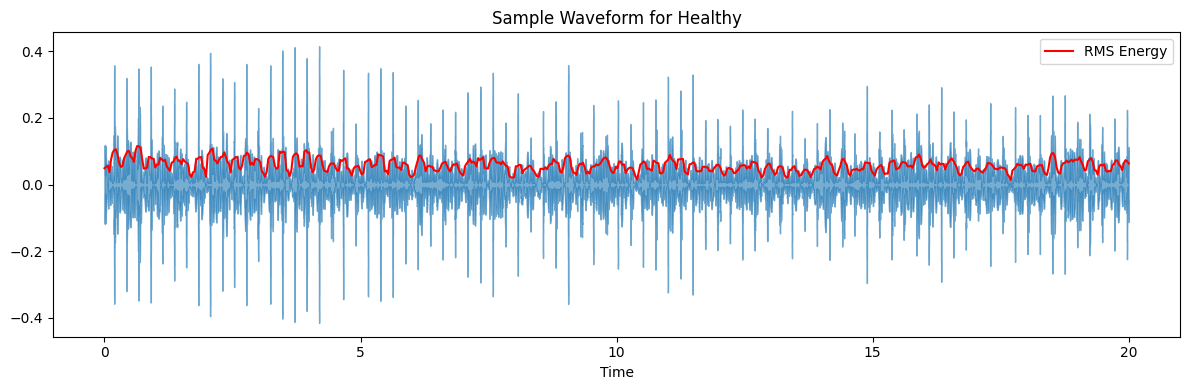

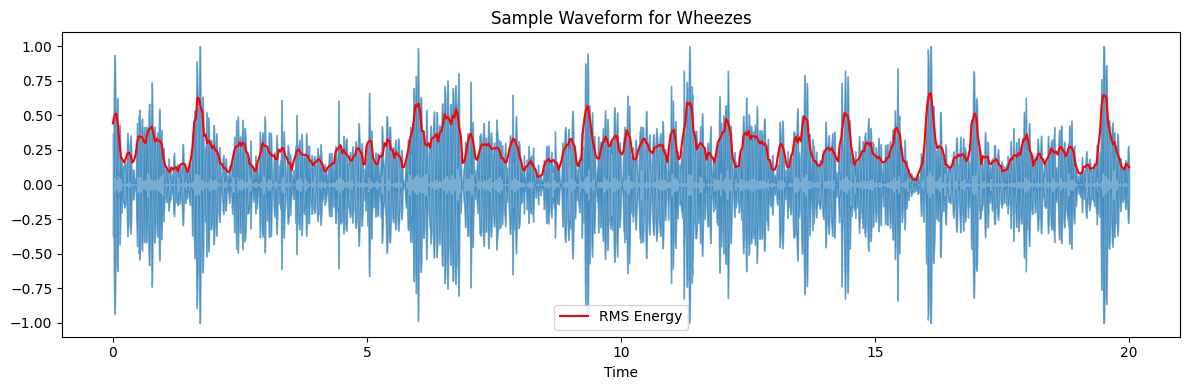

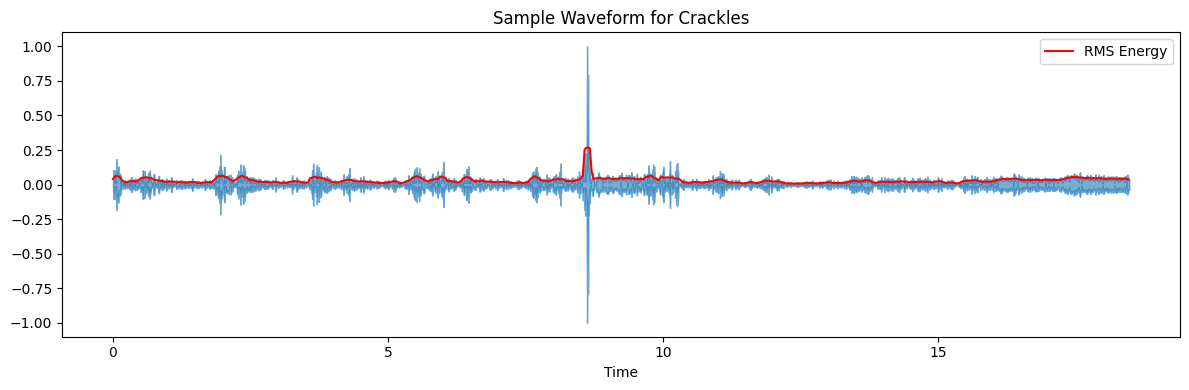

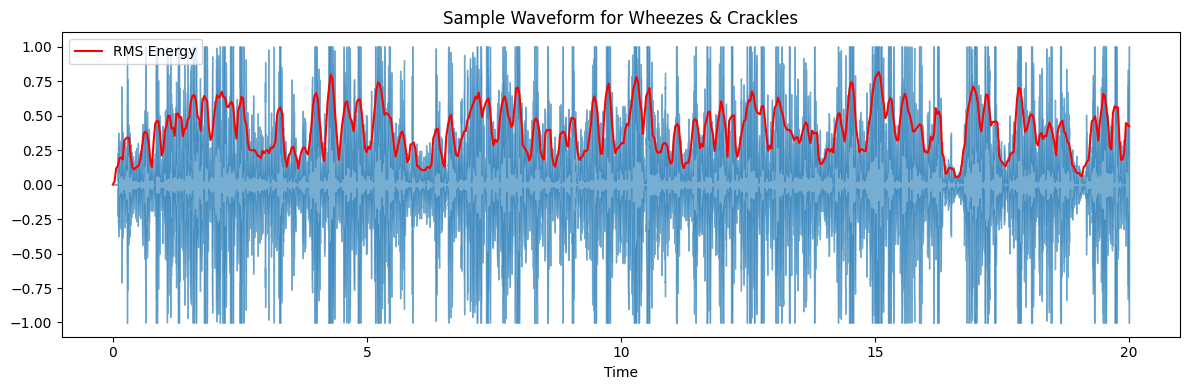

In [ ]:
target_diagnoses = ['Healthy', 'Wheezes', 'Crackles', 'Wheezes & Crackles']

# Define hop_length explicitly so both RMS and Time calculation use the same value
hop_length = 512

for diagnosis_type in target_diagnoses:
    # Find the first filename for the current diagnosis type
    # Note: Ensure 'summary' dataframe and 'root' path are defined in your environment
    example_filename = summary[summary['diagnosis'] == diagnosis_type].index[0]

    # Construct the full path to the WAV file
    wav_path = os.path.join(root, example_filename + '.wav')

    # Load the audio file
    x, sr = librosa.load(wav_path, sr=16000)

    # Calculate RMS energy
    # Explicitly passing hop_length ensures consistency
    rms = librosa.feature.rms(y=x, hop_length=hop_length)

    # We must tell times_like what the SR and hop_length are
    times = librosa.times_like(rms, sr=sr, hop_length=hop_length)

    # Create a figure and axes for plotting
    plt.figure(figsize=(12, 4))
    ax = plt.subplot(1, 1, 1)

    # Plot the waveform
    librosa.display.waveshow(y=x, sr=sr, ax=ax, alpha=0.6)

    # Overlay the RMS envelope
    ax.plot(times, rms[0], color='r', linestyle='-', label='RMS Energy')
    ax.legend()

    # Set plot title
    ax.set(title=f'Sample Waveform for {diagnosis_type}')
    plt.tight_layout()
    plt.show()

These waveforms show representative audio signals (raw amplitude in blue) and their RMS energy envelopes (red) for each diagnosis: Healthy, Wheezes, Wheezes & Crackles, and Crackles.

### Healthy

- The amplitude fluctuations are relatively moderate and evenly distributed over time, reflecting steady breathing cycles typical of healthy auscultation.
- RMS energy remains low and consistent, indicating stable airflow without abrupt sound events.

### Wheezes

- The waveform displays periodic bursts of increased amplitude, corresponding with cyclical peaks in RMS energy.
- These rises match the characteristic, continuous, and musical tones of wheezes, caused by airway narrowing or obstruction.

### Wheezes & Crackles

- The signal contains high variability in amplitude and frequent, prominent peaks throughout, reflecting mixed transient and periodic sound features.
- RMS energy is elevated, fluctuating more often and dramatically compared with other classes, consistent with the presence of both wheeze (continuous) and crackle (transient) events.

### Crackles

- Waveform is mostly low amplitude, punctuated by sudden, sharp spikes that coincide with isolated peaks in RMS energy.
- These spikes occur sporadically, reflecting the brief, explosive quality of crackles, typical of opening small airways or fluid movement in the lungs.

### Key Interpretation

- Healthy breath sounds are stable with low, steady energy.
- Wheezes show repeating cycles of elevated energy, reflecting persistent abnormal vibrations.
- Wheezes & Crackles present the most complex signals, with frequent and combined energy spikes.
- Crackles are characterized by isolated, abrupt energy events superimposed on quiet background signal.

This pattern of RMS energy and waveform shape supports distinguishing each condition and can be helpful for automated lung sound classification and clinical screening workflows.

## Extract Audio Features

In [ ]:
all_audio_features = []

for filename in tqdm(summary.index, desc="Extracting Audio Features"):
    wav_path = os.path.join(root, filename + '.wav')

    try:
        x, sr = librosa.load(wav_path, sr=16000) # Standardize sample rate to 16kHz

        # Get diagnosis
        diagnosis = summary.loc[filename, 'diagnosis']

        # Calculate duration
        duration = len(x) / sr

        # Calculate Spectral Centroid
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=x, sr=sr))

        # Calculate Spectral Bandwidth
        spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=x, sr=sr))

        # Calculate Spectral Roll-off
        spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=x, sr=sr))

        # Calculate Spectral Flux
        stft_result = librosa.stft(y=x)
        S = np.abs(stft_result)
        diff_S = np.diff(S, axis=1)
        spectral_flux = np.mean(np.sum(diff_S**2, axis=0))

        all_audio_features.append({
            'filename': filename,
            'diagnosis': diagnosis,
            'duration_sec': duration,
            'spectral_centroid': spectral_centroid,
            'spectral_bandwidth': spectral_bandwidth,
            'spectral_rolloff': spectral_rolloff,
            'spectral_flux': spectral_flux
        })

    except Exception as e:
        print(f"Error processing {filename}: {e}")
        all_audio_features.append({
            'filename': filename,
            'diagnosis': summary.loc[filename, 'diagnosis'] if filename in summary.index else 'Unknown',
            'duration_sec': None,
            'spectral_centroid': None,
            'spectral_bandwidth': None,
            'spectral_rolloff': None,
            'spectral_flux': None
        })

features_df = pd.DataFrame(all_audio_features)
print("Audio feature extraction complete.")
features_df.head()

Extracting Audio Features:   0%|          | 0/920 [00:00<?, ?it/s]

Audio feature extraction complete.


,filename,diagnosis,duration_sec,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flux
0,101_1b1_Al_sc_Meditron,Healthy,20.000,103.308684,428.665575,106.691793,1103.282227
1,101_1b1_Pr_sc_Meditron,Healthy,20.000,115.066286,545.371168,82.443091,347.812439
2,102_1b1_Ar_sc_Meditron,Healthy,20.000,146.119419,583.370430,141.773163,165.400772
3,103_2b2_Ar_mc_LittC2SE,Wheezes,20.000,107.104283,571.585362,40.435304,16187.585938
4,104_1b1_Al_sc_Litt3200,Healthy,15.856,120.760653,158.983849,237.729965,2411.239990


In [ ]:
mean_features_by_diagnosis = features_df.groupby('diagnosis')[['duration_sec', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flux']].mean()
print("Mean of audio features grouped by diagnosis:")
mean_features_by_diagnosis

Mean of audio features grouped by diagnosis:


,duration_sec,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flux
diagnosis,,,,,
Crackles,21.901635,358.017716,945.547264,498.373169,12804.363281
Healthy,21.227730,352.481058,852.795189,554.102420,9801.568359
Wheezes,20.825382,282.499853,722.072382,387.860291,11420.613281
Wheezes & Crackles,22.131975,254.426769,717.778652,323.368614,11803.405273


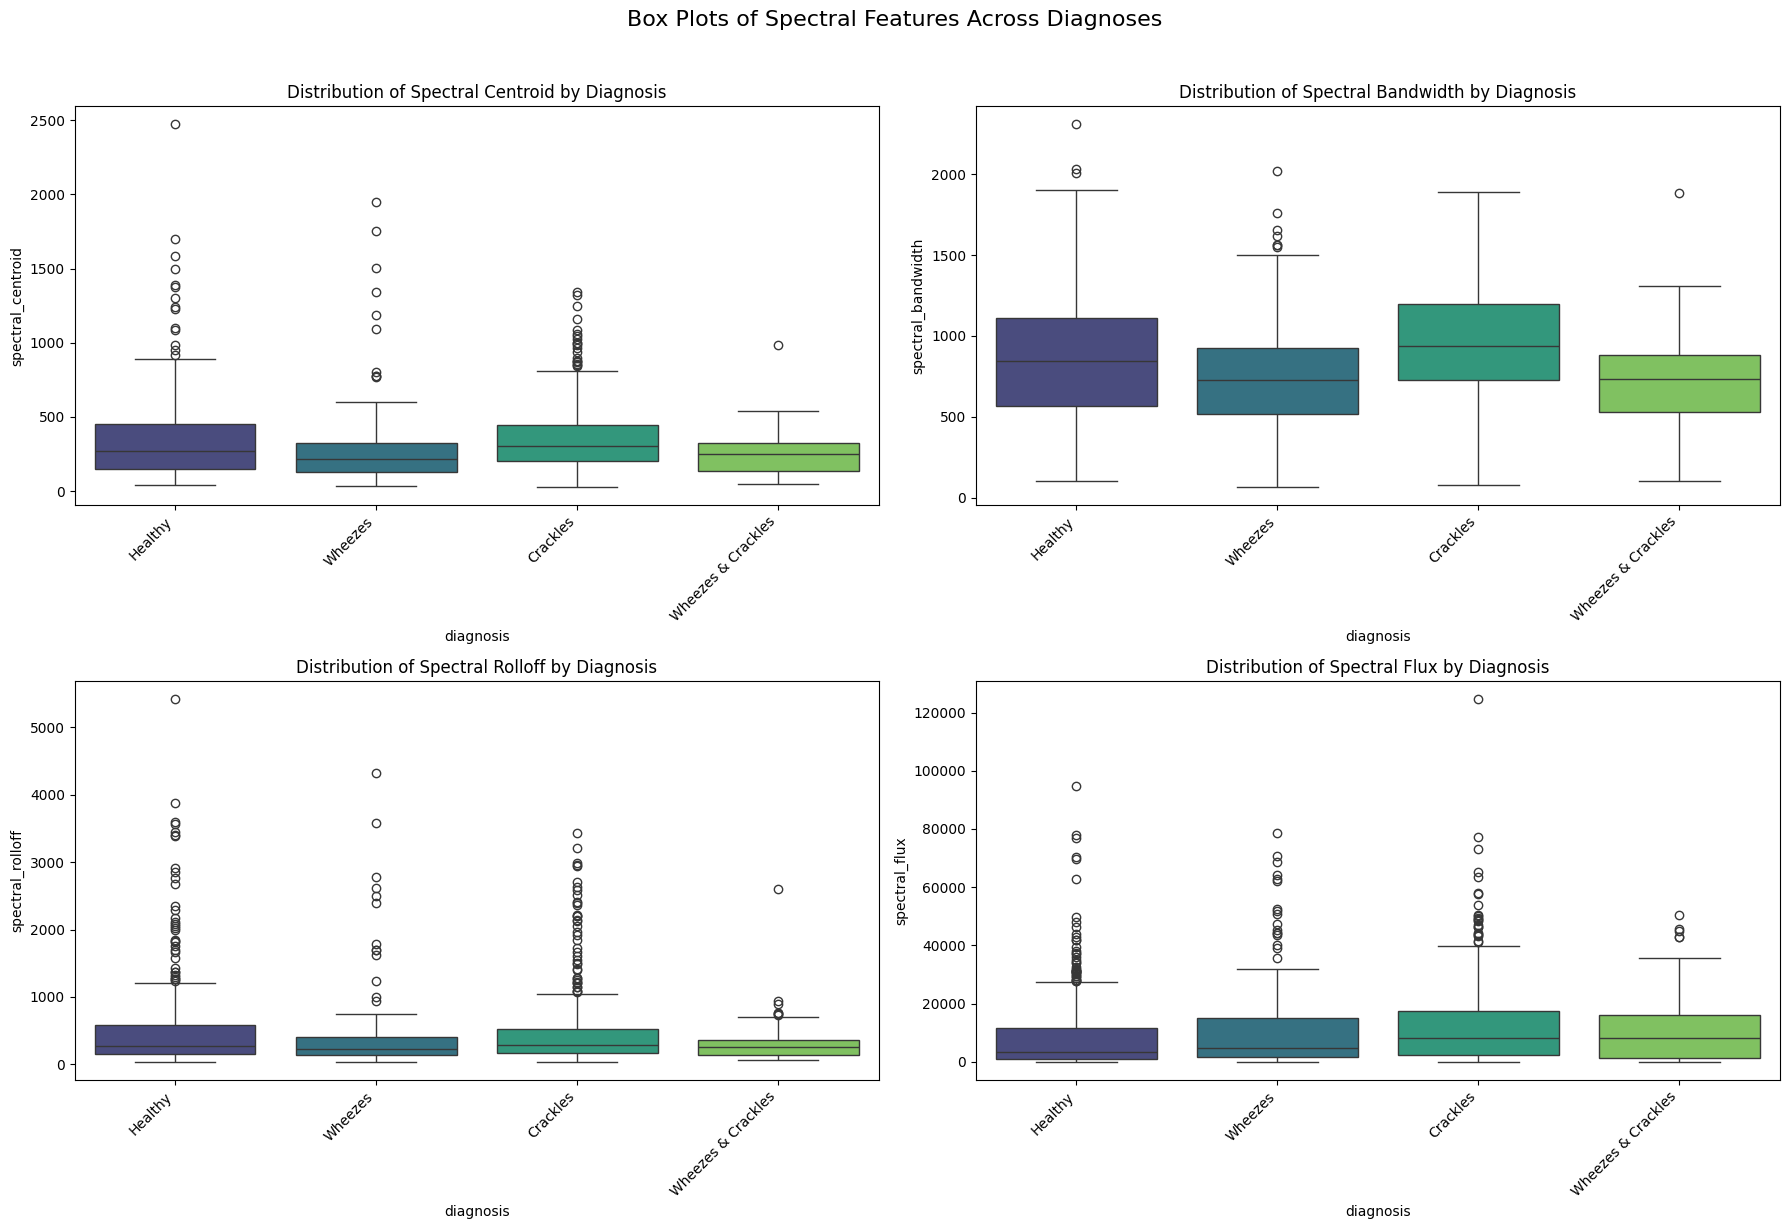

In [ ]:
spectral_features = ['spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flux']

plt.figure(figsize=(18, 12))

for i, feature in enumerate(spectral_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=features_df, x='diagnosis', y=feature, hue='diagnosis', palette='viridis', legend=False)
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Diagnosis')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.suptitle('Box Plots of Spectral Features Across Diagnoses', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

These present the distributions of key spectral audio features (Spectral Centroid, Bandwidth, Rolloff, Flux) for lung sound recordings grouped by diagnosis: Healthy, Wheezes, Crackles, and Wheezes & Crackles.

### Spectral Centroid

- Healthy and Crackles show higher median spectral centroid values than Wheezes and the combined diagnosis, indicating generally brighter (higher-frequency) sounds.
- Healthy sounds also present the largest spread and more extreme outliers, reflecting greater variability in frequency content.
- The lower medians for Wheezes and Wheezes & Crackles may reflect their more continuous or lower-pitched acoustic signatures.

### Spectral Bandwidth

- Crackles have the widest median spectral bandwidth, aligning with their broader frequency ranges and sharp, noisy characteristics.
- Healthy samples show the largest interquartile range, pointing to more variable frequency distribution in normal breathing sounds.
- Wheezes and Wheezes & Crackles are lower and more compact, consistent with their more tonal and narrow-band structure.

### Spectral Rolloff

- Healthy recordings yield the highest rolloff medians, reflecting greater energy in higher frequencies typical of unobstructed breathing.
- Crackles and Wheezes have lower medians, with Wheezes & Crackles lowest overall, suggesting reduced high-frequency components.
- Significant outliers in all groups highlight the heterogeneity among recordings for each diagnosis.

### Spectral Flux

- Crackles and Wheezes & Crackles display higher median spectral flux, consistent with frequent spectral changes and transients in abnormal lung sounds.
- Healthy recordings typically exhibit lower flux, indicating steadier frequency content and less abrupt audio changes.

### Clinical Insights

- **Healthy**: Higher centroid, bandwidth, and rolloff indicate normal, rich, and steady breathing sounds.
- **Crackles**: Higher centroid and flux mean, and broader bandwidth, reflect sharp bursts of energy and frequency — typical crackle characteristics.
- **Wheezes**: Lower centroid and bandwidth, plus lower flux, emphasize their tonal, persistent nature.
- **Combined**: Wheezes & Crackles generally follow Wheezes profile for centroid, bandwidth, and rolloff but have higher flux due to transient crackles mixed in.